# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


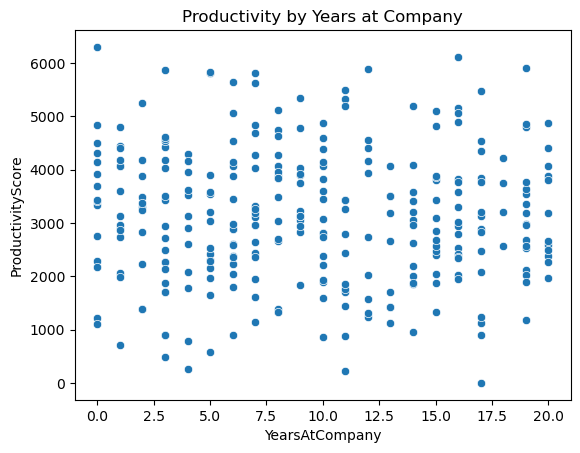

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.726
Time:                        15:26:40   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
sb.scatterplot(x="YearsAtCompany", y="ProductivityScore", data=df)
plt.title('Productivity by Years at Company')
plt.show()

X = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

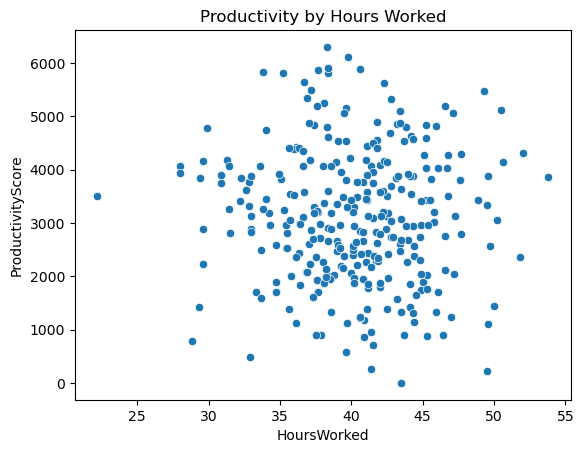

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.379
Time:                        15:26:41   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
sb.scatterplot(x="HoursWorked", y="ProductivityScore", data=df)
plt.title('Productivity by Hours Worked')
plt.show()

X = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

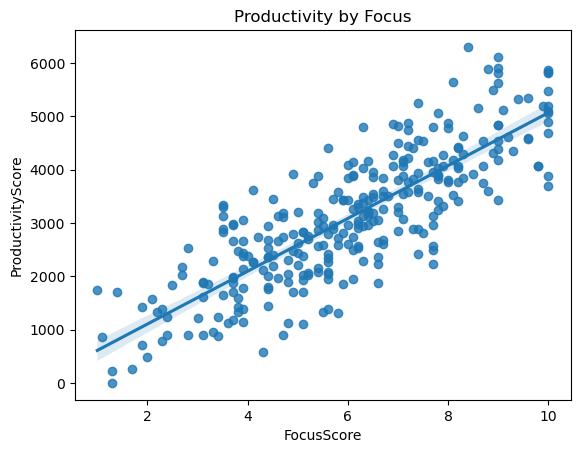

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Wed, 20 May 2026   Prob (F-statistic):           3.02e-75
Time:                        15:26:41   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
sb.regplot(x="FocusScore", y="ProductivityScore", data=df)
plt.title('Productivity by Focus')
plt.show()

X = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

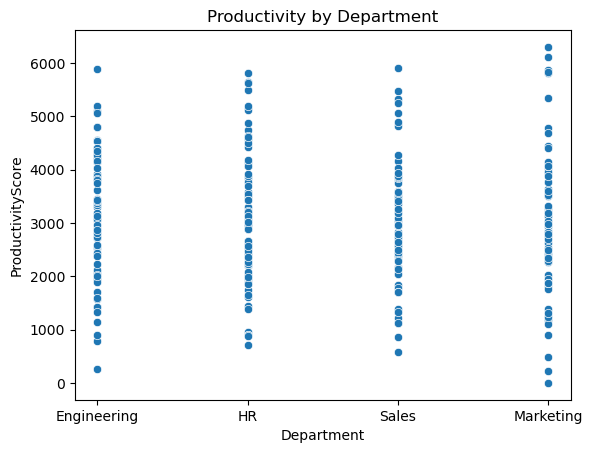

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2365
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.627
Time:                        15:26:41   Log-Likelihood:                -2564.0
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3160.8134    120.045     26.330      0.000    2924.571    3397.056
Department   -31.6626     65.103     -0.486      0.627    -159.783      96.458
==============================================================================
Omnibus:                        2.332   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.312   Jarque-Bera (JB):                2.056
Skew:                           0.101   Prob(JB):                        0.358
Kurtosis:                       2.648   Cond. No.                         3.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
sb.scatterplot(x="Department", y="ProductivityScore", data=df)
plt.title('Productivity by Department')
plt.show()

X = sm.add_constant(df['Department'].map({'Engineering': 0, 'HR': 1, 'Sales' : 2, 'Marketing' : 3}))
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

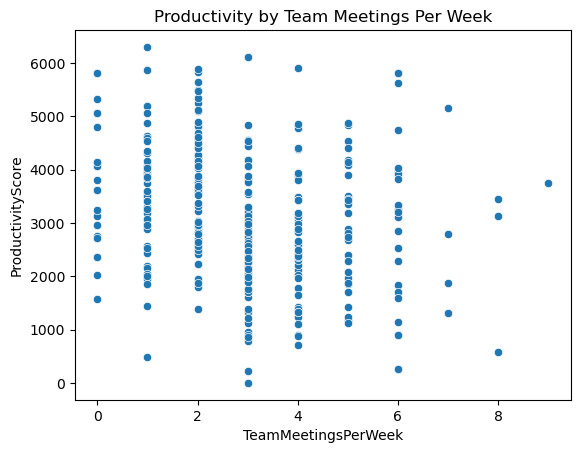

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     17.09
Date:                Wed, 20 May 2026   Prob (F-statistic):           4.63e-05
Time:                        15:26:41   Log-Likelihood:                -2555.8
No. Observations:                 300   AIC:                             5116.
Df Residuals:                     298   BIC:                             5123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3611.2745    139.247     25.934      0.000    3337.243    3885.306
TeamMeetingsPerWeek  -165.5197     40.036     -4.134      0.000    -244.309     -86.730
==============================================================================
Omnibus:                        2.592   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.274   Jarque-Bera (JB):                2.468
Skew:                           0.157   Prob(JB):                        0.291
Kurtosis:                       2.686   Cond. No.                         7.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
sb.scatterplot(x="TeamMeetingsPerWeek", y="ProductivityScore", data=df)
plt.title('Productivity by Team Meetings Per Week')
plt.show()

X = sm.add_constant(df['TeamMeetingsPerWeek'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

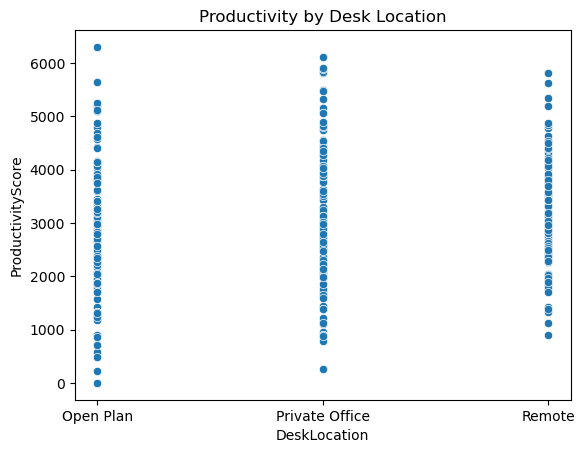

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     5.314
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0218
Time:                        15:26:41   Log-Likelihood:                -2561.5
No. Observations:                 300   AIC:                             5127.
Df Residuals:                     298   BIC:                             5134.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2917.0774    111.501     26.162      0.000    2697.648    3136.507
DeskLocation   206.0135     89.368      2.305      0.022      30.142     381.885
==============================================================================
Omnibus:                        2.870   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                2.609
Skew:                           0.149   Prob(JB):                        0.271
Kurtosis:                       2.654   Cond. No.                         2.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
sb.scatterplot(x="DeskLocation", y="ProductivityScore", data=df)
plt.title('Productivity by Desk Location')
plt.show()

X = sm.add_constant(df['DeskLocation'].map({'Open Plan': 0, 'Private Office': 1, 'Remote' : 2}))
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

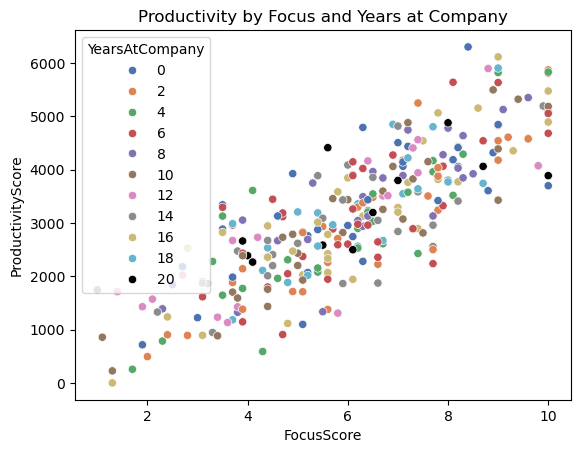

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Wed, 20 May 2026   Prob (F-statistic):           8.89e-74
Time:                        15:45:18   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             88.7215    145.130      0.611      0.541    -196.891     374.334
FocusScore       495.2145     19.816     24.990      0.000     456.217     534.212
YearsAtCompany     2.5120      6.904      0.364      0.716     -11.075      16.099
==============================================================================
Omnibus:                        0.768   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.681   Jarque-Bera (JB):                0.883
Skew:                           0.082   Prob(JB):                        0.643
Kurtosis:                       2.791   Cond. No.                         44.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
deep = sb.color_palette("deep", 10)
deep.append("black") #needed an 11th color :)
sb.scatterplot(x="FocusScore", y="ProductivityScore", data=df, hue=(df["YearsAtCompany"] // 2 * 2), palette=deep)
plt.title('Productivity by Focus and Years at Company')
plt.show()

X = sm.add_constant(df[['FocusScore', 'YearsAtCompany']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

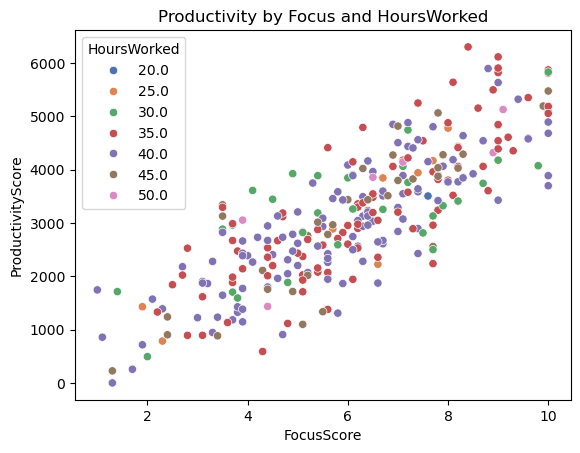

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Wed, 20 May 2026   Prob (F-statistic):           8.69e-74
Time:                        15:35:47   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         258.8336    366.985      0.705      0.481    -463.386     981.053
FocusScore    494.5564     19.820     24.953      0.000     455.551     533.561
HoursWorked    -3.5345      8.426     -0.419      0.675     -20.117      13.048
==============================================================================
Omnibus:                        0.803   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.669   Jarque-Bera (JB):                0.907
Skew:                           0.072   Prob(JB):                        0.635
Kurtosis:                       2.773   Cond. No.                         366.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
sb.scatterplot(x="FocusScore", y="ProductivityScore", data=df, hue=(df["HoursWorked"] // 5 * 5), palette="deep")
plt.title('Productivity by Focus and HoursWorked')
plt.show()

X = sm.add_constant(df[['FocusScore', 'HoursWorked']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

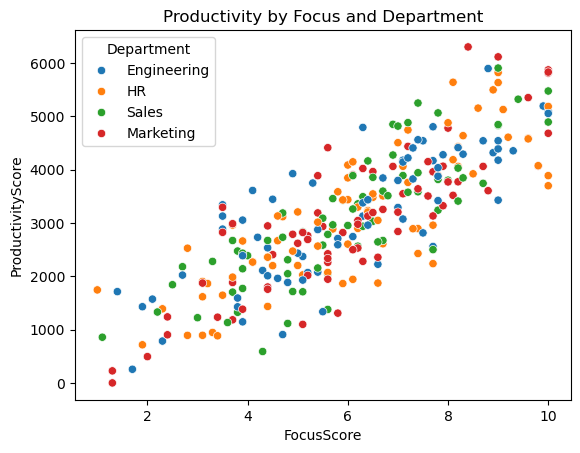

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     313.4
Date:                Wed, 20 May 2026   Prob (F-statistic):           6.56e-74
Time:                        15:26:41   Log-Likelihood:                -2393.9
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        161.2832    137.926      1.169      0.243    -110.153     432.719
FocusScore   494.9353     19.781     25.021      0.000     456.007     533.863
Department   -31.8478     36.991     -0.861      0.390    -104.646      40.950
==============================================================================
Omnibus:                        0.587   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.746   Jarque-Bera (JB):                0.712
Skew:                           0.076   Prob(JB):                        0.700
Kurtosis:                       2.816   Cond. No.                         22.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
sb.scatterplot(x="FocusScore", y="ProductivityScore", data=df, hue="Department")
plt.title('Productivity by Focus and Department')
plt.show()

df['Department'] = df['Department'].map({'Engineering': 0, 'HR': 1, 'Sales' : 2, 'Marketing' : 3})
X = sm.add_constant(df[['FocusScore', 'Department']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

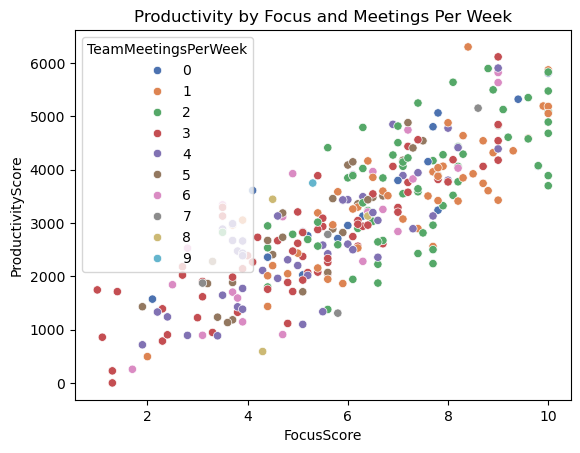

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     313.3
Date:                Wed, 20 May 2026   Prob (F-statistic):           6.79e-74
Time:                        15:26:41   Log-Likelihood:                -2393.9
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  21.3955    170.207      0.126      0.900    -313.570     356.361
FocusScore            500.2857     20.837     24.010      0.000     459.279     541.292
TeamMeetingsPerWeek    20.1564     24.630      0.818      0.414     -28.316      68.629
==============================================================================
Omnibus:                        0.419   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.811   Jarque-Bera (JB):                0.547
Skew:                           0.063   Prob(JB):                        0.761
Kurtosis:                       2.832   Cond. No.                         29.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
sb.scatterplot(x="FocusScore", y="ProductivityScore", data=df, hue="TeamMeetingsPerWeek", palette="deep")
plt.title('Productivity by Focus and Meetings Per Week')
plt.show()

X = sm.add_constant(df[['FocusScore', 'TeamMeetingsPerWeek']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

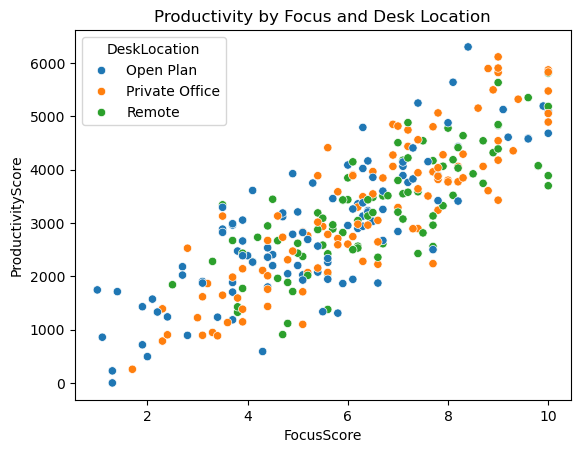

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     318.3
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.35e-74
Time:                        15:26:42   Log-Likelihood:                -2392.3
No. Observations:                 300   AIC:                             4791.
Df Residuals:                     297   BIC:                             4802.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          156.0322    127.784      1.221      0.223     -95.445     407.510
FocusScore     504.4458     20.254     24.906      0.000     464.586     544.306
DeskLocation  -103.8129     52.434     -1.980      0.049    -207.003      -0.623
==============================================================================
Omnibus:                        0.628   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.731   Jarque-Bera (JB):                0.737
Skew:                           0.039   Prob(JB):                        0.692
Kurtosis:                       2.770   Cond. No.                         20.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
sb.scatterplot(x="FocusScore", y="ProductivityScore", data=df, hue="DeskLocation")
plt.title('Productivity by Focus and Desk Location')
plt.show()

df["DeskLocation"] = df["DeskLocation"].map({'Open Plan': 0, 'Private Office': 1, 'Remote' : 2})
X = sm.add_constant(df[['FocusScore', 'DeskLocation']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

I didn't notice much correlation in the data. The only metric directly linked to an increased productivity score is the focus score. Once I noticed that, I decided to compare other metrics to focus in order to see if anything influenced that. Nothing necessarily stood out, but I noticed a slight trend in focus and meetings per week. There are some slight groups of different meeting counts along the line, with 1-2 meetings seeming to be grouped together somewhat higher than all others. 

directly addressing concerns. There seems to be no difference in productivity for older and newer employees. Remote workers are equally as productive (maybe slightly more at a glance) as in-office workers. Open-plan workers don't necessarily focus less, but they do seem to have a lower floor than the others so to speak. There doesn't seem to be any increase in productivity for overtime work, and there do seem to be too many meetings for ideal focus and productivity.

My advice to the company would simply be to encourage focus, and to keep meetings to a minimum, though make sure to have some.